# PART - A

### 1. What are Supervised Learning Algorithms?

Supervised learning is a type of machine learning where the model learns from data that has input and output values. It learns the relationship and predicts the output for new data.

### 2. Regression vs Classification

Regression is used to predict continuous values like house price or salary. Classification is used to predict categories like Yes/No, Pass/Fail, or Spam/Not Spam.

### 3. Simple Linear Regression

Simple Linear Regression is used to predict a continuous value using one input feature. Its basic equation is:

**y = b₀ + b₁x**

### 4. Assumptions of Linear Regression

The main assumptions are:
- Linear relationship between variables
- Independent observations
- Constant variance of errors
- Normally distributed residuals
- No high multicollinearity

### 5. Bias-Variance Trade-Off

Bias is the error caused by a model being too simple, while variance happens when a model is too sensitive to training data. A good model should maintain a balance between bias and variance.

### 6. Overfitting and Underfitting

**Overfitting** happens when a model performs very well on training data but poorly on test data. **Underfitting** happens when the model is too simple and performs poorly on both training and test data.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

# PART - B

In [26]:
df = pd.read_csv("D:\\RW\\RW_Exam\\ML\\PR-1\\RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")
display(df.head())
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print(df.info())
display(df.describe())

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


Rows: 4200
Columns: 12
Missing values: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB
None


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


In [27]:
X = df.drop(columns=["house_id", "house_price_inr"])
y = df["house_price_inr"]
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool', 'renovation_years_ago']

Target:
house_price_inr


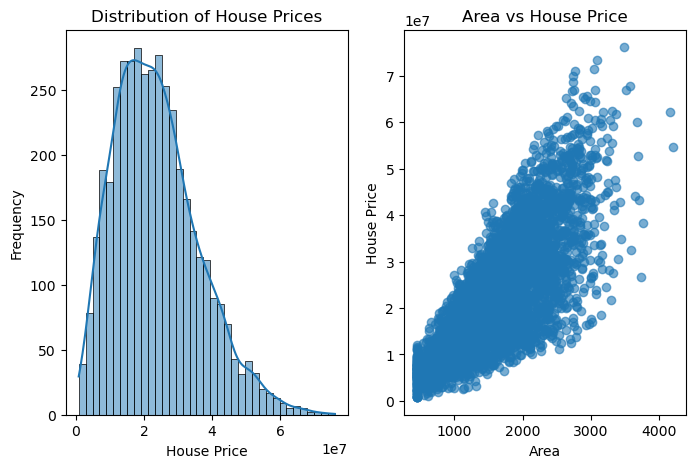

In [28]:
plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
sns.histplot(df["house_price_inr"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.subplot(1, 2, 2)
plt.scatter(df["area_sqft"],df["house_price_inr"],alpha=0.6)
plt.xlabel("Area")
plt.ylabel("House Price")
plt.title("Area vs House Price")
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 3360
Testing: 840


# PART - C

In [30]:
X_simple = df[["area_sqft"]]
y = df["house_price_inr"]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple,y,test_size=0.20,random_state=42)

model = LinearRegression()
model.fit(X_train_s, y_train_s)

print("slope:", model.coef_[0])
print("Intercept:", model.intercept_)

slope: 14788.306111307533
Intercept: -1163519.1764185987


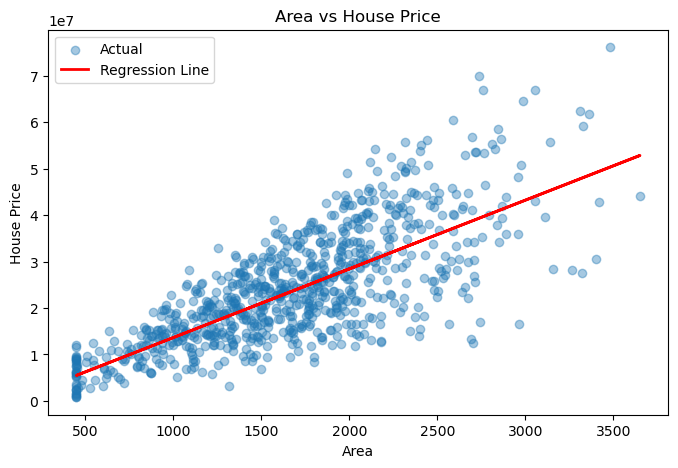

In [31]:
y_pred_simple = model.predict(X_test_s)
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s["area_sqft"],y_test_s,
    alpha=0.4,label="Actual")

plt.plot(X_test_s["area_sqft"],y_pred_simple,linewidth=2,
    label="Regression Line",color="red")

plt.xlabel("Area")
plt.ylabel("House Price")
plt.title("Area vs House Price")
plt.legend()

plt.show()

# PART - D

In [32]:
mse = mean_squared_error(y_test_s, y_pred_simple)
mae = mean_absolute_error(y_test_s, y_pred_simple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, y_pred_simple)

n = len(y_test_s)
p = X_test_s.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)
print("Adjusted R²:", adjusted_r2)

MSE: 66989260021849.47
MAE: 6294593.696131912
RMSE: 8184696.696997969
R² Score: 0.5625199587991578
Adjusted R²: 0.5619979062440257


# PART - E

In [33]:
X = df.drop(columns=["house_id", "house_price_inr"])
y = df["house_price_inr"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

y_pred_multiple = multiple_model.predict(X_test)

mse_multiple = mean_squared_error(y_test, y_pred_multiple)
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2_multiple = 1 - ((1 - r2_multiple) * (n - 1) / (n - p - 1))

print("Multiple Linear Regression:")
print("MSE:", mse_multiple)
print("MAE:", mae_multiple)
print("RMSE:", rmse_multiple)
print("R²:", r2_multiple)
print("Adjusted R²:", adjusted_r2_multiple)

Multiple Linear Regression:
MSE: 12592918884127.623
MAE: 2604991.4061556906
RMSE: 3548650.29048054
R²: 0.9177606877509897
Adjusted R²: 0.9167686574464178


In [34]:
comparison = pd.DataFrame({
    "Metric": ["MSE", "MAE", "RMSE", "R²", "Adjusted R²"],
    "Simple Linear Regression": [
        mse,mae,rmse,
        r2,adjusted_r2],
    "Multiple Linear Regression": [
        mse_multiple,mae_multiple,rmse_multiple,
        r2_multiple,adjusted_r2_multiple]
})

comparison

,Metric,Simple Linear Regression,Multiple Linear Regression
0,MSE,6.698926e+13,1.259292e+13
1,MAE,6.294594e+06,2.604991e+06
2,RMSE,8.184697e+06,3.548650e+06
3,R²,5.625200e-01,9.177607e-01
4,Adjusted R²,5.619979e-01,9.167687e-01


A positive coefficient indicates that, holding other features constant, an increase in that feature is associated with an increase in predicted house price.

# PART - F

In [35]:
X_poly = df[["area_sqft"]]
y = df["house_price_inr"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly,y,test_size=0.20,random_state=42)

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_model.fit(X_train_p, y_train_p)
y_pred_poly = poly_model.predict(X_test_p)

mse_poly = mean_squared_error(y_test_p, y_pred_poly)
mae_poly = mean_absolute_error(y_test_p, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test_p, y_pred_poly)

n = len(y_test_p)
p = 2
adjusted_r2_poly = 1 - ((1 - r2_poly) * (n - 1) / (n - p - 1))

print("Polynomial Regression:")
print("MSE:", mse_poly)
print("MAE:", mae_poly)
print("RMSE:", rmse_poly)
print("R²:", r2_poly)
print("Adjusted R²:", adjusted_r2_poly)

Polynomial Regression:
MSE: 66962947122198.38
MAE: 6292394.561281691
RMSE: 8183089.094113444
R²: 0.5626917978136464
Adjusted R²: 0.5616468558729384


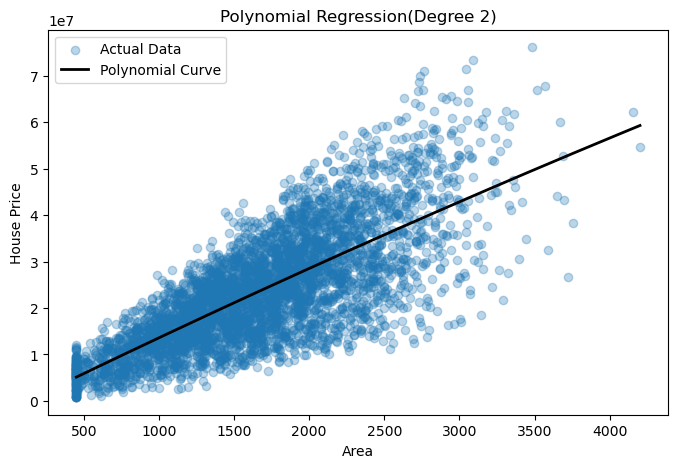

In [36]:
x_range = np.linspace(X_poly["area_sqft"].min(),X_poly["area_sqft"].max(),300).reshape(-1, 1)

y_curve = poly_model.predict(pd.DataFrame(x_range, columns=["area_sqft"]))

plt.figure(figsize=(8, 5))
plt.scatter(X_poly["area_sqft"],y,alpha=0.3,label="Actual Data")

plt.plot(x_range,y_curve,linewidth=2,label="Polynomial Curve",color="Black")
plt.xlabel("Area")
plt.ylabel("House Price")
plt.title("Polynomial Regression(Degree 2)")
plt.legend()

plt.show()

In [37]:
model_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression"
    ],
    "MSE": [
        mse,
        mse_multiple,
        mse_poly
    ],
    "MAE": [
        mae,
        mae_multiple,
        mae_poly
    ],
    "RMSE": [
        rmse,
        rmse_multiple,
        rmse_poly
    ],
    "R2": [
        r2,
        r2_multiple,
        r2_poly
    ],    
    "Adjusted_R2": [
        adjusted_r2,
        adjusted_r2_multiple,
        adjusted_r2_poly
    ]
})

model_comparison

,Model,MSE,MAE,RMSE,R2,Adjusted_R2
0,Simple Linear Regression,6.698926e+13,6.294594e+06,8.184697e+06,0.562520,0.561998
1,Multiple Linear Regression,1.259292e+13,2.604991e+06,3.548650e+06,0.917761,0.916769
2,Polynomial Regression,6.696295e+13,6.292395e+06,8.183089e+06,0.562692,0.561647


In [38]:
train_pred_poly = poly_model.predict(X_train_p)

train_r2_poly = r2_score(y_train_p, train_pred_poly)
test_r2_poly = r2_score(y_test_p, y_pred_poly)

print("Training R²:", train_r2_poly)
print("Testing R²:", test_r2_poly)


if train_r2_poly > test_r2_poly:
    print("The model is overfitting the training data.")
    
if train_r2_poly < 0.5 and test_r2_poly < 0.5:
    print("The model is underfitting the data.")

Training R²: 0.5724674245504779
Testing R²: 0.5626917978136464
The model is overfitting the training data.


# PART - G

In [39]:
X_gd = df[["area_sqft"]].values
y_gd = df["house_price_inr"].values

scaler = StandardScaler()
X_gd_scaled = scaler.fit_transform(X_gd)

In [40]:
def batch_gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    n = len(X)
    w = 0.0
    b = 0.0
    loss_history = []
    for epoch in range(epochs):
        y_pred = w * X.flatten() + b
        error = y_pred - y
        dw = (2 / n) * np.sum(error * X.flatten())
        db = (2 / n) * np.sum(error)
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
        mse = np.mean(error ** 2)
        loss_history.append(mse)
    
    return w, b, loss_history

w_batch, b_batch, batch_loss = batch_gradient_descent(X_gd_scaled,y_gd,learning_rate=0.01,epochs=1000)

print("Weight:", w_batch)
print("Bias:", b_batch)

Weight: 9360815.640521202
Bias: 23641886.37783052


Stochastic Gradient Descent — Scratch

In [41]:
def stochastic_gradient_descent(X,y,learning_rate=0.01,epochs=50):
    
    n = len(X)
    w = 0.0
    b = 0.0
    
    loss_history = []
    for epoch in range(epochs):
        indices = np.random.permutation(n)
        for i in indices:
            
            xi = X[i][0]
            yi = y[i]
            
            y_pred = w * xi + b
            
            error = y_pred - yi
            
            dw = 2 * error * xi
            db = 2 * error
            
            w = w - learning_rate * dw
            b = b - learning_rate * db
        
        predictions = w * X.flatten() + b
        
        loss = np.mean((predictions - y) ** 2)
        loss_history.append(loss)
    
    return w, b, loss_history

w_sgd, b_sgd, sgd_loss = stochastic_gradient_descent(X_gd_scaled,y_gd,learning_rate=0.001,epochs=50)

print("Weight:", w_sgd)
print("Bias:", b_sgd)

Weight: 9431013.226399578
Bias: 23517615.922738604


Mini-Batch Gradient Descent

In [42]:
def mini_batch_gradient_descent(X,y,learning_rate=0.01,epochs=100,batch_size=32):
    
    n = len(X)
    w = 0.0
    b = 0.0
    
    loss_history = []
    
    for epoch in range(epochs):
        
        indices = np.random.permutation(n)
        
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for start in range(0, n, batch_size):
            
            end = start + batch_size
            
            X_batch = X_shuffled[start:end].flatten()
            y_batch = y_shuffled[start:end]
            
            y_pred = w * X_batch + b
            
            error = y_pred - y_batch
            
            dw = (2 / len(X_batch)) * np.sum(
                error * X_batch
            )
            
            db = (2 / len(X_batch)) * np.sum(error)
            
            w = w - learning_rate * dw
            b = b - learning_rate * db
        
        predictions = w * X.flatten() + b
        
        loss = np.mean((predictions - y) ** 2)
        loss_history.append(loss)
    
    return w, b, loss_history

w_mini, b_mini, mini_loss = mini_batch_gradient_descent(X_gd_scaled,y_gd,learning_rate=0.01,epochs=100,batch_size=32)

print("Weight:", w_mini)
print("Bias:", b_mini)

Weight: 9360549.286369463
Bias: 23759364.779423147


# PART - H

In [43]:
y_train_pred_simple = model.predict(X_train_s)
y_train_pred_multiple = multiple_model.predict(X_train)
y_train_pred_poly = poly_model.predict(X_train_p)

y_test_pred_simple = model.predict(X_test_s)
y_test_pred_multiple = multiple_model.predict(X_test)
y_test_pred_poly = poly_model.predict(X_test_p)

bias_variance = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression"
    ],
    "Train R²": [
        r2_score(y_train_s, y_train_pred_simple),
        r2_score(y_train, y_train_pred_multiple),
        r2_score(y_train_p, y_train_pred_poly)
    ],
    "Test R²": [
        r2_score(y_test_s, y_test_pred_simple),
        r2_score(y_test, y_test_pred_multiple),
        r2_score(y_test_p, y_test_pred_poly)
    ]
})

bias_variance["R² Gap"] = (bias_variance["Train R²"] -bias_variance["Test R²"])

bias_variance.round(4)

,Model,Train R²,Test R²,R² Gap
0,Simple Linear Regression,0.5723,0.5625,0.0098
1,Multiple Linear Regression,0.9247,0.9178,0.0070
2,Polynomial Regression,0.5725,0.5627,0.0098


In [44]:
print("""
As model complexity increases, the model becomes more flexible
and can capture more complex relationships in the data.

A simple model may have high bias and underfit the data.
A more complex model can reduce bias and improve prediction accuracy,
but excessive complexity can increase variance and cause overfitting.

Therefore, increasing complexity does not always reduce test error.
The ideal model should achieve good test performance without a
large gap between training and testing performance.
""")


As model complexity increases, the model becomes more flexible
and can capture more complex relationships in the data.

A simple model may have high bias and underfit the data.
A more complex model can reduce bias and improve prediction accuracy,
but excessive complexity can increase variance and cause overfitting.

Therefore, increasing complexity does not always reduce test error.
The ideal model should achieve good test performance without a
large gap between training and testing performance.



In [45]:
bias_variance["Train RMSE"] = [
    np.sqrt(mean_squared_error(y_train_s, y_train_pred_simple)),
    np.sqrt(mean_squared_error(y_train, y_train_pred_multiple)),
    np.sqrt(mean_squared_error(y_train_p, y_train_pred_poly))
]

bias_variance["Test RMSE"] = [
    np.sqrt(mean_squared_error(y_test_s, y_test_pred_simple)),
    np.sqrt(mean_squared_error(y_test, y_test_pred_multiple)),
    np.sqrt(mean_squared_error(y_test_p, y_test_pred_poly))
]

best_model = bias_variance.sort_values(by=["Test R²", "R² Gap"],ascending=[False, True]).iloc[0]

print("Best Bias-Variance Balanced Model:")
print(best_model["Model"])

print("\nTest R²:", round(best_model["Test R²"], 4))
print("Train R²:", round(best_model["Train R²"], 4))
print("R² Gap:", round(best_model["R² Gap"], 4))
print("Test RMSE:", round(best_model["Test RMSE"], 2))

print("""
Conclusion:
The selected model provides a good balance between prediction
performance and generalization. A small difference between training
and testing performance indicates that the model is not excessively
overfitting the training data.
""")

Best Bias-Variance Balanced Model:
Multiple Linear Regression

Test R²: 0.9178
Train R²: 0.9247
R² Gap: 0.007
Test RMSE: 3548650.29

Conclusion:
The selected model provides a good balance between prediction
performance and generalization. A small difference between training
and testing performance indicates that the model is not excessively
overfitting the training data.



# PART - I

1. Best-performing model and why?
- The best-performing model is the one with the highest accuracy or lowest error rate, depending on the specific task and evaluation metric used.
2. impact of gradient descent optimization?
- Gradient descent optimization helps in minimizing the loss function, leading to better model performance. It allows the model to learn from the data iteratively and converge towards optimal parameters.
3. Evidence of overfitting/underfitting?
- Overfitting occurs when the model performs well on training data but poorly on validation or test data, indicating that it has learned noise or specific patterns in the training set. Underfitting occurs when the model is too simple to capture the underlying patterns in the data, resulting in poor performance on both training and validation/test sets. Evidence can be observed through metrics such as accuracy, loss curves, and validation scores.
4. Practical businees interpretation of results?
- The practical business interpretation of the results involves understanding how the model's predictions can inform decision-making. For example, if the model predicts house prices accurately, it can help real estate agents set competitive prices, assist buyers in making informed decisions, and guide investors in identifying profitable opportunities. Additionally, understanding the impact of different features on house prices can help businesses focus on key factors that drive value in the housing market.

5